<a href="https://colab.research.google.com/github/aleakucing/PCVK26_14_IBRA/blob/main/P1_TugasD2_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt


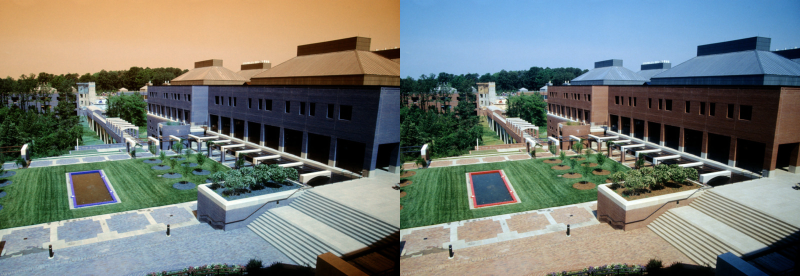

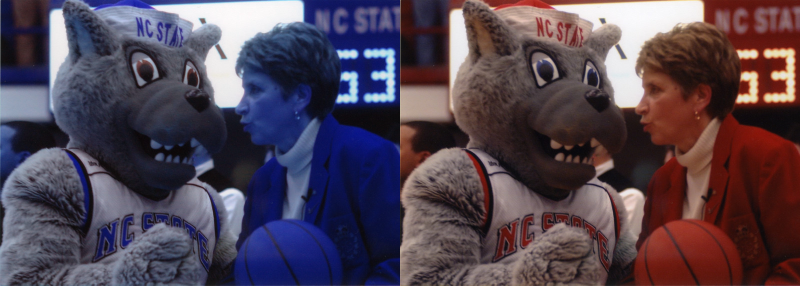

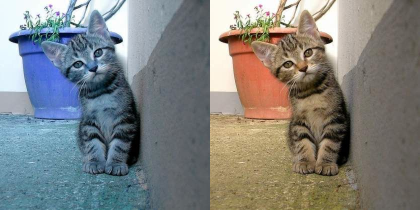

In [44]:
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://i.ibb.co.com/Dn87VGk/a1ffb493b2e05fe95c4e41a8d0c28ca9.jpg"]

for url in urls:
    image = io.imread(url)
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    final_frame = cv.hconcat((image, image_2))
    cv2_imshow(final_frame)
    print('\n')

resolusi image: tinggi x lebar =  210  x  210


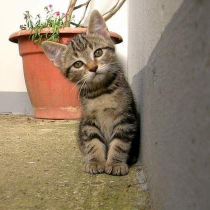

In [45]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ", tinggi, " x ", lebar)
cv2_imshow(image_2)

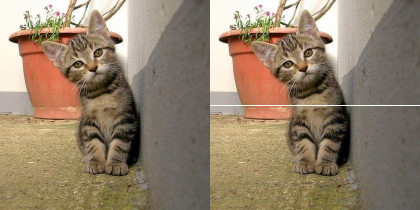

In [46]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

for y in range (lebar):
  image_3[int((tinggi)/2),y] = [255,255,255]

final_frame = cv.hconcat((image_2,image_3))
cv2_imshow(final_frame)

PERTANYAAN

1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan
menggunakan Google Colab?
- Sebenarnya bisa dilakukan menggunakan laptop pribadi, tetapi membuatuhkan spesifikasi CPU&GPU yang cukup tinggi, dan kita tidak perlu install/konfigurasi python dan liblary lagi karena sudah disediakan oleh google collab

2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke
delapan? Apakah semua library tersebut harus digunakan dalam praktikum
sesi ini?
- skimage: mengunduh/membaca gambar mentah ke python  
- numpy: menerima deretan angka piksel mentah, lalu menyusunnya rapi ke dalam   koordinat baris, kolom, dan layer warna
- cv2: mengecilkan resolusi , mengubah kanal warna , dan menggabungkan gambar
- cv2_imshow: Merender matriks angka tadi kembali menjadi tampilan gambar visual di layar notebook Colab
- pandas: mengelola data yang memiliki nama kolom, tipe data bervariasi (teks, tanggal, angka), dan catatan informasi lainnya. tidak karena ada library yang belum digunakan seperti pd, transform, plt, sebenarnya pandas belum terpakai secara fungsional dalam pemrosesan piksel visual sederhana ini.

3. Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut :
Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak
dilakukan?
- kode tersebut berfungsi untuk memperkecil dimensi citra 50% dari ukuran aslinya, jika tidak dilakukan menyebabkan komputasi iterasi pixel yang cukup banyak, dan membutuhkan waktu dan proses yang lebih lama

4. Perhatikan potongan kode progam berikut :
Apakah kegunaan kode [255,255,255] ? Jelaskan!
- kode tersebut adalah menentukan instensitas berwarna putih pada RGB

5. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun rendah!
- pixel adalah unit dasar matrix yang memuat informasi insentitas warna dari sebuah citra digital, resolusi adalah kerapatan dan total pixel dari sebuah citra biasanya lebar x tinggi,  

resolusi tinggi: memiliki jumlah pixel yang lebih padat, sehingga object bisa dilihat lebih tajam, halus, dan tidak mudah pecah jika di zoom, tetapi memililiki ukuran file yang cukup besar, komputasi lebih berat

resolusi rendah: memiliki jumlah pixel yang lebih sedikit, sehingga object tidak bisa dilihat lebih tajam, agak kasar, dan mudah pecah jika di zoom, tetapi memiliki ukuran file yang cukup kecil, komputasi lebih ringan

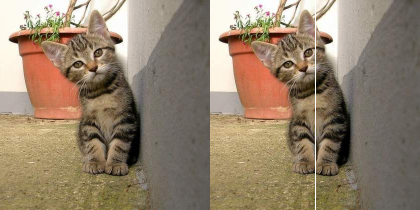

In [47]:
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
for x in range (tinggi):
  image_3[x, int((lebar)/2)] = [255,255,255]

final_frame = cv.hconcat((image_2,image_3))
cv2_imshow(final_frame)

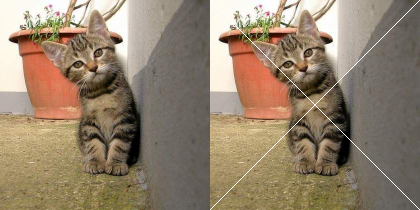

In [48]:
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

for x in range(tinggi):
    y1 = int(x * (lebar / tinggi))
    if 0 <= y1 < lebar:
        image_3[x, y1] = [255, 255, 255]

    y2 = int((tinggi - 1 - x) * (lebar / tinggi))
    if 0 <= y2 < lebar:
        image_3[x, y2] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

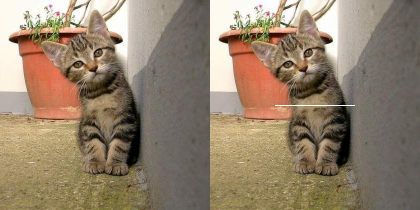

In [49]:
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

panjang = 80

tengah_y = int(lebar / 2)
tengah_x = int(tinggi / 2)

start_y = tengah_y - int(panjang / 2)
end_y = tengah_y + int(panjang / 2)

for y in range(start_y, end_y):
    image_3[tengah_x, y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

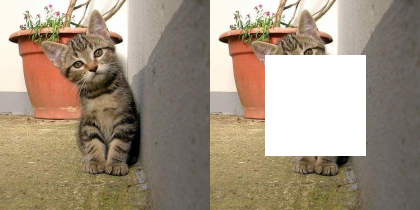

In [50]:
image = io.imread(urls[2])
image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

h, w = image_3.shape[:2]

box_size = 100
center_x = w // 2
center_y = h // 2

start_x = center_x - (box_size // 2)
start_y = center_y - (box_size // 2)
end_x = center_x + (box_size // 2)
end_y = center_y + (box_size // 2)

image_3 = cv.rectangle(image_3.copy(), (start_x, start_y), (end_x, end_y), (255, 255, 255), -1)

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)